In [1]:
from s2gos_apps.processes.common import generation, simulation
from s2gos_apps.processes.gobabeb import generation_configs, simulation_configs

In [3]:
scene_name = "gobabeb"
target_lat =  -23.6015417
target_lon =  15.1258696
target_size = 10
gmt_hour = 9
spp = 8

# expands the parameters passed to full configuration files for generation and simulation
gen_config_path = generation_configs(
    scene_name,
    target_lat,
    target_lon,
    target_size,
    config_output_dir="./use_cases/gen_config",
    scene_output_dir="./use_cases/gen_output",
)

sim_config_path = simulation_configs(
    scene_name,
    target_lat,
    target_lon,
    target_size,
    gmt_hour,
    config_output_dir="./use_cases/sim_config",
)



Configuring generation...
Basic configuration created
Configuration validation passed
[mitsuba] Warning: Couldn't import the ipywidgets package. Installing this package is required for the system to properly log messages and print in Jupyter notebooks!


INFO:joseki.profiles.factory:Registering profile afgl_1986-tropical
INFO:joseki.profiles.factory:Registering profile afgl_1986-midlatitude_summer
INFO:joseki.profiles.factory:Registering profile afgl_1986-midlatitude_winter
INFO:joseki.profiles.factory:Registering profile afgl_1986-subarctic_summer
INFO:joseki.profiles.factory:Registering profile afgl_1986-subarctic_winter
INFO:joseki.profiles.factory:Registering profile afgl_1986-us_standard
INFO:joseki.profiles.factory:Registering profile mipas_2007-midlatitude_day
INFO:joseki.profiles.factory:Registering profile mipas_2007-midlatitude_night
INFO:joseki.profiles.factory:Registering profile mipas_2007-polar_summer
INFO:joseki.profiles.factory:Registering profile mipas_2007-polar_winter
INFO:joseki.profiles.factory:Registering profile mipas_2007-tropical
INFO:joseki.profiles.factory:Registering profile ussa_1976
/home/norman/projects/s2gos-apps/.pixi/envs/default/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not 



Configuring simulation...


[#################################] 100% de421.bsp


Simulation configured:
  Sensors: 1
    1. uav_rgb_camera (uav/perspective_camera)
  Saved: simulation_config.json


In [4]:
# generate the 3D scene description from the generation config
scene_description_path = generation.generation(gen_config_path)



Generating scene description...
Configuration validation

Configuration Summary:
  Scene: gobabeb
  Location: -23.6015°, 15.1259°
  AOI: 10.0 km²
  Resolution: 10.0 m
Generating scene with configuration

Generating DAG visualization


INFO:root:Importing assets from XML: /home/norman/projects/s2gos-apps/extra_data/hypernets_mast_better.xml
INFO:root:Parsed /home/norman/projects/s2gos-apps/extra_data/hypernets_mast_better.xml: found 4 materials and 5 shapes
INFO:root:Successfully converted 4 materials from XML
INFO:root:Successfully imported 5 assets from /home/norman/projects/s2gos-apps/extra_data/hypernets_mast_better.xml
INFO:root:Importing assets from XML: /home/norman/projects/s2gos-apps/extra_data/gobabeb_fence_custom.xml
INFO:root:Parsed /home/norman/projects/s2gos-apps/extra_data/gobabeb_fence_custom.xml: found 2 materials and 566 shapes
INFO:root:Successfully converted 2 materials from XML
INFO:root:Successfully imported 566 assets from /home/norman/projects/s2gos-apps/extra_data/gobabeb_fence_custom.xml
INFO:root:Registered 17 resources:
INFO:root:  Core (7): aoi, target_dem, target_landcover, target_mesh, target_texture, target_vegetation, scene_description
INFO:root:  Buffer (5): buffer_aoi, buffer_dem, b


Resource execution order:
  aoi (depends on: none)
  target_dem (depends on: ['aoi'])
  target_landcover (depends on: ['aoi'])
  target_mesh (depends on: ['target_dem'])
  target_texture (depends on: ['target_landcover'])
  buffer_aoi (depends on: ['aoi'])
  buffer_dem (depends on: ['buffer_aoi'])
  buffer_landcover (depends on: ['buffer_aoi'])
  buffer_mesh (depends on: ['buffer_dem'])
  buffer_texture (depends on: ['buffer_landcover'])
  background_aoi (depends on: ['aoi'])
  background_landcover (depends on: ['background_aoi'])
  background_texture (depends on: ['background_landcover'])
  user_assets (depends on: ['target_dem'])
  hamster_data (depends on: ['aoi', 'buffer_aoi', 'background_aoi'])
  target_vegetation (depends on: ['target_landcover', 'target_dem'])
  scene_description (depends on: ['target_mesh', 'target_texture', 'buffer_mesh', 'buffer_texture', 'background_texture', 'user_assets', 'hamster_data'])


INFO:root:Copernicus-DEM-30 saved to use_cases/gen_output/gobabeb/data/dem_gobabeb_10.0m.zarr
INFO:root:Target DEM: use_cases/gen_output/gobabeb/data/dem_gobabeb_10.0m.zarr
INFO:root:ESA Worldcover 2021 saved to use_cases/gen_output/gobabeb/data/landcover_gobabeb_10.0m.zarr
INFO:root:Target landcover (10.0m): use_cases/gen_output/gobabeb/data/landcover_gobabeb_10.0m.zarr
INFO:root:Mesh saved to use_cases/gen_output/gobabeb/meshes/gobabeb_terrain.ply
INFO:root:Target mesh: use_cases/gen_output/gobabeb/meshes/gobabeb_terrain.ply
INFO:root:Texture: use_cases/gen_output/gobabeb/textures/gobabeb_10.0m_selection.png
INFO:root:Target texture: use_cases/gen_output/gobabeb/textures/gobabeb_10.0m_selection.png
INFO:root:Copernicus-DEM-30 saved to use_cases/gen_output/gobabeb/data/dem_buffer_gobabeb_60.0m.zarr
INFO:root:ESA Worldcover 2021 saved to use_cases/gen_output/gobabeb/data/landcover_buffer_gobabeb_60.0m.zarr
INFO:root:Buffer landcover (60.0m): use_cases/gen_output/gobabeb/data/landcover_

Scene generated successfully!
 Location: -23.6015417, 15.1258696
 Target: 10.0km² at 10.0m
  Buffer: 60.0km at 60.0m
  Background: 150.0km at 200.0m
  Output: use_cases/gen_output/gobabeb

Output directory: use_cases/gen_output/gobabeb


In [5]:
# simulate an observation from the scene description and simulation config
simulation_output_dire = simulation.simulation(
    f"./use_cases/gen_output/{scene_name}/{scene_name}.yml",
    sim_config_path,
    f"./use_cases/sim_output/{scene_name}"
)



Simulating observation...


INFO:root:Successfully loaded spectral data: /home/norman/projects/s2gos-apps/packages/s2gos-generator/resources/data/spectra/spectrum_baresoil_high.nc (variable: reflectance)
INFO:root:Successfully loaded spectral data: /home/norman/projects/s2gos-apps/packages/s2gos-generator/resources/data/spectra/spectrum_concrete.nc (variable: reflectance)
INFO:root:Successfully loaded spectral data: /home/norman/projects/s2gos-apps/packages/s2gos-generator/resources/data/spectra/spectrum_cropland_foliage_uniform.nc (variable: reflectance)
INFO:root:Successfully loaded spectral data: /home/norman/projects/s2gos-apps/packages/s2gos-generator/resources/data/spectra/spectrum_cropland_foliage_uniform.nc (variable: transmittance)
INFO:root:Successfully loaded spectral data: /home/norman/projects/s2gos-apps/packages/s2gos-generator/resources/data/spectra/spectrum_grassland_rpv_high.nc (variable: rho_0)
INFO:root:Successfully loaded spectral data: /home/norman/projects/s2gos-apps/packages/s2gos-generator


Validating materials and running simulation...
Using SceneDescription object for validation...
Available materials: ['baresoil', 'concrete', 'cropland', 'grassland', 'mangroves', 'mat_antenna', 'mat_metal', 'mat_pole', 'mat_solar', 'metal_posts', 'moss', 'rough_aluminum', 'shrubland', 'shrubs_tls_tree_336_mat_leaves', 'shrubs_tls_tree_336_mat_wood', 'snow', 'steel_wire', 'treecover', 'trees_tls_tree_38_mat_leaves', 'trees_tls_tree_38_mat_wood', 'trees_tls_tree_71_mat_leaves', 'trees_tls_tree_71_mat_wood', 'water', 'wetland']
✅ All 577 object material references are valid
Using SceneDescription object for simulation
Eradiate simulation: config_simulation
  Sensors: 1
  Measurements: 0

Workflow: Standard


INFO:root:Successfully loaded spectral data: /home/norman/projects/s2gos-apps/extra_data/spectra/pole_soil.nc (variable: reflectance)
INFO:root:Created interpolated spectrum: 3 wavelength points from 440.0 to 660.0 nm
INFO:root:Successfully loaded spectral data: /home/norman/projects/s2gos-apps/packages/s2gos-generator/resources/data/spectra/spectrum_moss.nc (variable: reflectance)
INFO:root:Successfully loaded spectral data: /home/norman/projects/s2gos-apps/packages/s2gos-generator/resources/data/spectra/spectrum_shrubland_diffuse.nc (variable: reflectance)
INFO:root:Successfully loaded spectral data: /home/norman/projects/s2gos-apps/extra_data/spectra/patagonia_leaves_fur004_t1_b1_00010_reflectance.nc (variable: reflectance)
INFO:root:Successfully loaded spectral data: /home/norman/projects/s2gos-apps/extra_data/spectra/patagonia_bark_fur004_t2_bark00007_reflectance.nc (variable: reflectance)
INFO:root:Successfully loaded spectral data: /home/norman/projects/s2gos-apps/packages/s2gos

  Using simple mono atmosphere (GECKO + US Standard) for fast debugging


...

measures =[{'id': 'uav_rgb_camera', 'spp': 8, 'srf': {'type': 'multi_delta', 'wavelengths': [440.0, 550.0, 660.0]}, 'origin': [0.0, 0.0, 10722.534602547792], 'type': 'perspective', 'fov': 50.0, 'film_resolution': [512, 512], 'target': [0.0, 0.0, 0.0], 'up': [0.0, 1.0, 0.0]}]


INFO:joseki.profiles.schema:Dataset is valid
INFO:eradiate.experiments._core:Initializing kernel scene
INFO:joseki.profiles.schema:Dataset is valid


  Measure 1/1: uav_rgb_camera


INFO:eradiate.experiments._core:Launching simulation
Eradiate [660 nm]: 3/3|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 00:52, ETA=00:00
INFO:eradiate.experiments._core:Post-processing results


  ✓ Saved 'uav_rgb_camera' → config_simulation_uav_rgb_camera.zarr
RGB image saved to: use_cases/sim_output/gobabeb/uav_rgb_camera_rgb.png
Simulation completed successfully!

Output directory: ./use_cases/sim_output/gobabeb


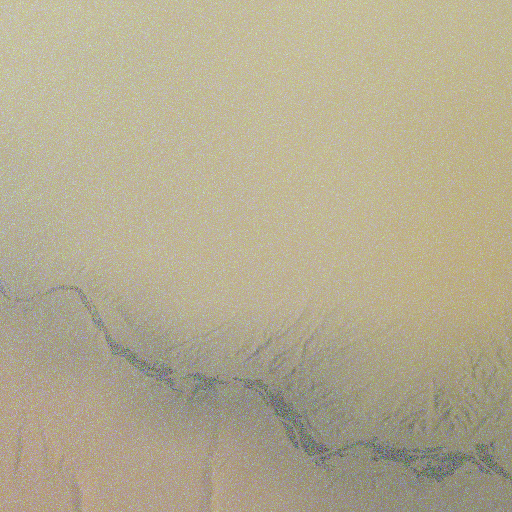

In [6]:
from IPython.display import Image, display

display(Image(filename="use_cases/sim_output/gobabeb/uav_rgb_camera_rgb.png"))